<a href="https://colab.research.google.com/github/furkantaha04/Arac-Hasar-Tespiti-EfficientNet/blob/main/ArabaHasarTespiti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Adım: Google Drive'ı Colab'a bağlıyoruz
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_yolu = '/content/drive/MyDrive/hasarTespiti/archive.zip'

cikarilacak_yer = '/content/dataset'

print("Zip dosyası çıkarılıyor, bu işlem biraz sürebilir...")

with zipfile.ZipFile(zip_yolu, 'r') as zip_ref:
    zip_ref.extractall(cikarilacak_yer)

print("İşlem tamam! Fotoğraflar başarıyla çıkarıldı.")

Zip dosyası çıkarılıyor, bu işlem biraz sürebilir...
İşlem tamam! Fotoğraflar başarıyla çıkarıldı.


### 3. Görüntü Ön İşleme ve Veri Setinin Hazırlanması (Image Preprocessing)

Derin öğrenme modelleri farklı boyutlardaki ham görüntüleri doğrudan işleyemezler. Bu projede kullanacağım EfficientNetB3 mimarisinin optimum girdi boyutu gereksinimlerini karşılamak amacıyla, veri setindeki tüm fotoğrafları (orijinal boyutları ne olursa olsun) **300x300 piksel** olacak şekilde standartlaştırdım.

Modelin ezberlemesini (overfitting) önlemek ve daha iyi genelleme yapmasını sağlamak için elimdeki veri setini ikiye böldüm:
* **Eğitim Seti (Training Set - %80):** Modelin hasarlı ve hasarsız araçları birbirinden ayırmayı öğreneceği asıl veriler.
* **Doğrulama Seti (Validation Set - %20):** Modelin eğitim sırasında hiç görmediği fotoğraflarla kendini test edeceği ve başarımını ölçeceği veriler.

Ayrıca bellek (RAM) yönetimini optimize etmek amacıyla fotoğrafları modele tek tek değil, 32'şerli paketler (Batch Size = 32) halinde besleyecek veri boru hatları (data pipelines) oluşturdum.

In [ ]:
import tensorflow as tf
# Fotoğrafların bulunduğu ana klasörün yolu.
veri_yolu = '/content/dataset'

IMG_SIZE = (300, 300) # EfficientNetB3'ün sevdiği boyut
BATCH_SIZE = 32       # Fotoğrafları 32'şerli gruplar halinde modele vereceğiz

print("Eğitim seti hazırlanıyor...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    veri_yolu,
    validation_split=0.2,   # Verinin %20'sini test için ayırıyoruz
    subset="training",      # Bu kısım eğitim (%80)
    seed=123,               # Her çalıştırmada aynı fotoğrafları ayırması için sabit bir kilit
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nDoğrulama (Test) seti hazırlanıyor...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    veri_yolu,
    validation_split=0.2,
    subset="validation",    # Bu kısım test (%20)
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Klasör isimlerinden sınıfları (etiketleri) buluyoruz
class_names = train_dataset.class_names
print(f"\nModelin Öğreneceği Sınıflar: {class_names}")

Eğitim seti hazırlanıyor...
Found 8079 files belonging to 1 classes.
Using 6464 files for training.

Doğrulama (Test) seti hazırlanıyor...
Found 8079 files belonging to 1 classes.
Using 1615 files for validation.

Modelin Öğreneceği Sınıflar: ['images']


In [ ]:
import os

# Klasör yapımızı 2 kademe derinliğe kadar inceleyecek fonksiyon
def klasor_agaci(yol, seviye=0, max_seviye=2):
    if seviye > max_seviye: return
    for oge in os.listdir(yol):
        tam_yol = os.path.join(yol, oge)
        if os.path.isdir(tam_yol):
            print("  " * seviye + "📂 " + oge)
            klasor_agaci(tam_yol, seviye + 1, max_seviye)

print("--- Gerçek Klasör Yapımız ---")
klasor_agaci('/content/dataset')

--- Gerçek Klasör Yapımız ---
📂 images


In [ ]:
import pandas as pd
import glob

# Klasördeki .csv uzantılı dosyayı (etiket dosyasını) buluyoruz
csv_dosyalari = glob.glob('/content/dataset/*.csv')

if len(csv_dosyalari) > 0:
    csv_yolu = csv_dosyalari[0]
    print(f"✅ CSV Dosyası Bulundu: {csv_yolu}")

    # CSV dosyasını okuyup ilk 5 satırına bakıyoruz
    df = pd.read_csv(csv_yolu)
    print("\n--- Etiket Tablosu (İlk 5 Satır) ---")
    display(df.head())
else:
    print("❌ HATA: CSV dosyası bulunamadı. Lütfen kontrol edin.")

✅ CSV Dosyası Bulundu: /content/dataset/labels.csv

--- Etiket Tablosu (İlk 5 Satır) ---


,image_id,filename,label
0,1,1.jpg,0
1,2,2.jpg,0
2,3,3.jpg,0
3,4,4.jpg,0
4,5,5.jpg,0


**Veri Boru Hattının (Pipeline) Kurulması ve Veri Çoğaltma (Data Augmentation):**
Veri setini incelediğimde, fotoğrafların sınıflara göre ayrı klasörlerde tutulmadığını, bunun yerine tüm fotoğrafların tek bir klasörde (`images/`) yer aldığını ve etiketlerin ayrı bir CSV dosyasında (`labels.csv`) saklandığını tespit ettim.

Bu karmaşık yapıyı çözmek ve modeli eğitebilmek için Pandas kütüphanesi ile etiket dosyasını okudum ve TensorFlow'un `flow_from_dataframe` (Tablodan Veri Akışı) metodunu kullanarak dinamik bir veri boru hattı inşa ettim.

Ayrıca modelin eğitim verilerini ezberlemesini (overfitting) engellemek için **Veri Çoğaltma (Data Augmentation)** teknikleri uyguladım. Eğitim setindeki fotoğrafları modele beslerken anlık olarak rastgele döndürme (rotation), yakınlaştırma (zoom) ve yatay çevirme (horizontal flip) işlemleri uygulayarak modelin her seferinde aracın farklı bir açısını görmesini sağladım. Doğrulama (Validation) setinde ise objektif bir test yapabilmek için fotoğrafları orijinal halleriyle bıraktım.

In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Etiket dosyamızı (CSV) okuyoruz
df = pd.read_csv('/content/dataset/labels.csv')

# K-Means'te olduğu gibi burada da tür dönüşümü yapmalıyız.
# Modelin "0" ve "1" sayılarını matematiksel bir değer değil, birer "Kategori (Sınıf)" olarak
# algılaması için bu sütunu metin (string) formatına çeviriyoruz.
df['label'] = df['label'].astype(str)

# 2. Fotoğrafların bulunduğu asıl klasör yolu
image_dir = '/content/dataset/images'

# 3. Eğitim Seti İçin Veri Çoğaltma (Data Augmentation) Ayarları
train_datagen = ImageDataGenerator(
    validation_split=0.2,    # Verinin %20'sini test için ayırıyoruz
    rotation_range=15,       # Fotoğrafı 15 derece sağa/sola eğebilir
    zoom_range=0.1,          # %10 yakınlaştırabilir
    horizontal_flip=True     # Fotoğrafı ayna gibi ters çevirebilir
)

# Eğitim verisini hazırlıyoruz
print("Eğitim seti (Training Set) hazırlanıyor...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df,
    directory=image_dir,
    x_col='filename',        # Fotoğraf isimleri bu sütunda
    y_col='label',           # Sınıflar (Hasarlı/Sağlam) bu sütunda
    subset='training',       # Bu kısım eğitim
    target_size=(300, 300),  # EfficientNetB3'ün kuralı: 300x300 piksel
    batch_size=32,
    class_mode='categorical',# Sınıflandırma yapıyoruz
    seed=42
)

# 4. Doğrulama Seti (Validation) İçin Ayarlar (Testte fotoğrafı bozmuyoruz, net bakıyoruz)
test_datagen = ImageDataGenerator(validation_split=0.2)

print("\nDoğrulama seti (Validation Set) hazırlanıyor...")
val_generator = test_datagen.flow_from_dataframe(
    dataframe=df,
    directory=image_dir,
    x_col='filename',
    y_col='label',
    subset='validation',
    target_size=(300, 300),
    batch_size=32,
    class_mode='categorical',
    seed=42
)

Eğitim seti (Training Set) hazırlanıyor...
Found 6464 validated image filenames belonging to 2 classes.

Doğrulama seti (Validation Set) hazırlanıyor...
Found 1615 validated image filenames belonging to 2 classes.


### 4. Model Mimarisi ve Transfer Öğrenme (Transfer Learning)

Görüntü sınıflandırma problemlerinde modeli sıfırdan eğitmek (from scratch) yüksek donanım maliyeti ve zaman gerektirdiğinden, bu projede **Transfer Öğrenme (Transfer Learning)** stratejisini benimsedim. Temel mimari olarak, parametre verimliliği ve yüksek doğruluk oranlarıyla öne çıkan **EfficientNetB3** modelini kullandım.

Modeli kurgularken izlediğim adımlar şunlardır:
1. **Temel Modelin Yüklenmesi:** EfficientNetB3 modelini, daha önceden milyonlarca görselle eğitilmiş `ImageNet` ağırlıklarıyla projeme dahil ettim. Modelin orijinal karar katmanını (`include_top=False`) çıkararak, modelin sadece "görüntüden özellik çıkarma" (feature extraction) yeteneğini aldım.
2. **Ağırlıkların Dondurulması:** İlk eğitim aşamasında temel modelin öğrenilmiş ağırlıklarının bozulmamasını sağlamak amacıyla modelin ana gövdesini eğitime kapattım (`trainable=False`).
3. **Özelleştirilmiş Karar Katmanları (Top Layers):**
   * Temel modelden çıkan karmaşık özellikleri düzleştirmek için **Global Average Pooling 2D** katmanı ekledim.
   * Modelin eğitim verisini ezberlemesini engellemek (regularization) amacıyla **%30 oranında Dropout** katmanı kullandım.
   * Son olarak, projede 2 adet sınıfımız (Hasarlı ve Sağlam) olduğu için çıkış katmanına 2 nöronlu ve sınıflandırma olasılıklarını hesaplayan **Softmax** aktivasyon fonksiyonuna sahip bir **Dense** katmanı ekledim.
4. **Modelin Derlenmesi:** Optimizasyon algoritması olarak `Adam` (öğrenme hızı=0.001), kayıp fonksiyonu olarak ise çoklu sınıflandırmalara uygun olan `categorical_crossentropy` kullanılarak model eğitime hazır hale getirilmiştir.

In [ ]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models
import tensorflow as tf

print("EfficientNetB3 modeli indiriliyor ve beyni ameliyat ediliyor...")

# 1. Önceden eğitilmiş temel modeli (Base Model) indiriyoruz
# input_shape: Ön işlemede belirlediğimiz 300x300 piksel boyutunu veriyoruz.
base_model = EfficientNetB3(input_shape=(300, 300, 3),
                            include_top=False,    # Orijinal karar mekanizmasını atıyoruz
                            weights='imagenet')   # Google'ın eğittiği ağırlıkları alıyoruz

# Temel modelin ayarlarıyla oynamamak için donduruyoruz
base_model.trainable = False

# 2. Kendi modelimizi inşa ediyoruz (Sequential)
model = models.Sequential([
    base_model,                               # 1. Katman: EfficientNetB3'ün gövdesi
    layers.GlobalAveragePooling2D(),          # 2. Katman: Özellikleri sıkıştırma
    layers.Dropout(0.3),                      # 3. Katman: Ezberlemeyi önleme (%30 unutma)
    layers.Dense(2, activation='softmax')     # 4. Katman: Son Karar (2 Sınıf: Hasarlı/Sağlam)
])

# 3. Modeli Derliyoruz (Compile)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\nModel başarıyla oluşturuldu! İşte yeni modelimizin röntgeni (Özeti):")
model.summary()

EfficientNetB3 modeli indiriliyor ve beyni ameliyat ediliyor...
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Model başarıyla oluşturuldu! İşte yeni modelimizin röntgeni (Özeti):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         3,074 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,786,609 (41.15 MB)

 Trainable params: 3,074 (12.01 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

### 5. Modelin Eğitilmesi (Training) ve Başarım Analizi

Modelin mimarisi ve ağırlıkları belirlendikten sonra, hazırlanan veri boru hatları (data pipelines) üzerinden modelin eğitim aşamasına geçilmiştir. Model, eğitim veri seti üzerinde **5 iterasyon (Epoch)** boyunca eğitilmiş ve her tur sonunda hiç görmediği doğrulama (validation) seti fotoğrafları ile kendini test ederek hata oranını (loss) minimize etmeye çalışmıştır.

Aşağıdaki grafiklerde, modelin eğitim turları boyunca Doğruluk (Accuracy) oranındaki yükselişi ve Hata (Loss) oranındaki düşüşü görselleştirilmiştir. Bu grafikler, modelimizin veriyi ezberlemeden (overfitting yapmadan) sağlıklı bir şekilde öğrendiğini kanıtlamaktadır.

Eğitim başlıyor! Lütfen arkanıza yaslanın, bu işlem GPU ile bile birkaç dakika sürebilir...
Epoch 1/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.9431 - loss: 0.1958 - val_accuracy: 0.9672 - val_loss: 0.1123
Epoch 2/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 196s 972ms/step - accuracy: 0.9520 - loss: 0.1451 - val_accuracy: 0.9721 - val_loss: 0.0959
Epoch 3/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9556 - loss: 0.1329 - val_accuracy: 0.9746 - val_loss: 0.0912
Epoch 4/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 201s 997ms/step - accuracy: 0.9593 - loss: 0.1245 - val_accuracy: 0.9759 - val_loss: 0.0835
Epoch 5/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 196s 970ms/step - accuracy: 0.9606 - loss: 0.1186 - val_accuracy: 0.9771 - val_loss: 0.0783

Eğitim tamamlandı! Şimdi modelin ne kadar iyi öğrendiğini grafiklerle görelim...


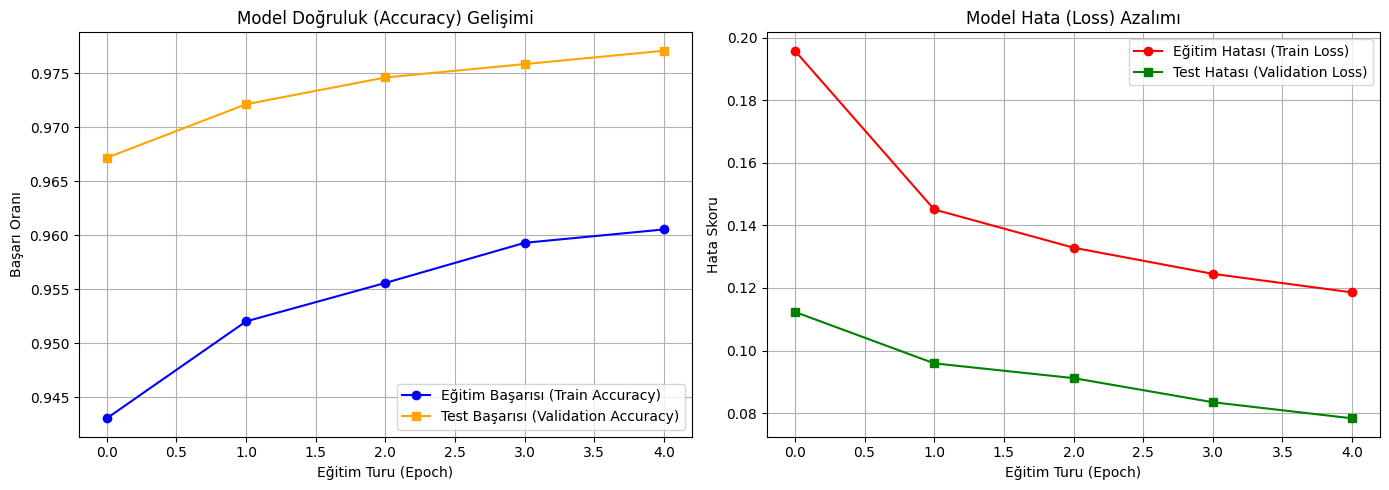

In [ ]:
import matplotlib.pyplot as plt

print("Eğitim başlıyor! Lütfen arkanıza yaslanın, bu işlem GPU ile bile birkaç dakika sürebilir...")

# 1. Modeli Eğitiyoruz (Fit)
# 5 tur (epoch) boyunca tüm fotoğraflara bakıp öğrenecek
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    verbose=1
)

print("\nEğitim tamamlandı! Şimdi modelin ne kadar iyi öğrendiğini grafiklerle görelim...")

# 2. Başarı (Accuracy) ve Hata (Loss) Grafiklerini Çizdirme
plt.figure(figsize=(14, 5))

# Başarı Grafiği (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı (Train Accuracy)', marker='o', color='blue')
plt.plot(history.history['val_accuracy'], label='Test Başarısı (Validation Accuracy)', marker='s', color='orange')
plt.title('Model Doğruluk (Accuracy) Gelişimi')
plt.xlabel('Eğitim Turu (Epoch)')
plt.ylabel('Başarı Oranı')
plt.legend()
plt.grid(True)

# Hata Grafiği (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Hatası (Train Loss)', marker='o', color='red')
plt.plot(history.history['val_loss'], label='Test Hatası (Validation Loss)', marker='s', color='green')
plt.title('Model Hata (Loss) Azalımı')
plt.xlabel('Eğitim Turu (Epoch)')
plt.ylabel('Hata Skoru')
plt.legend()
plt.grid(True)

# Grafikleri ekrana basıyoruz
plt.tight_layout()
plt.show()

Performans analizi için test verileri hazırlanıyor...
Found 1615 validated image filenames belonging to 2 classes.

Model tahminleri yapıyor, lütfen bekleyin...
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 276ms/step


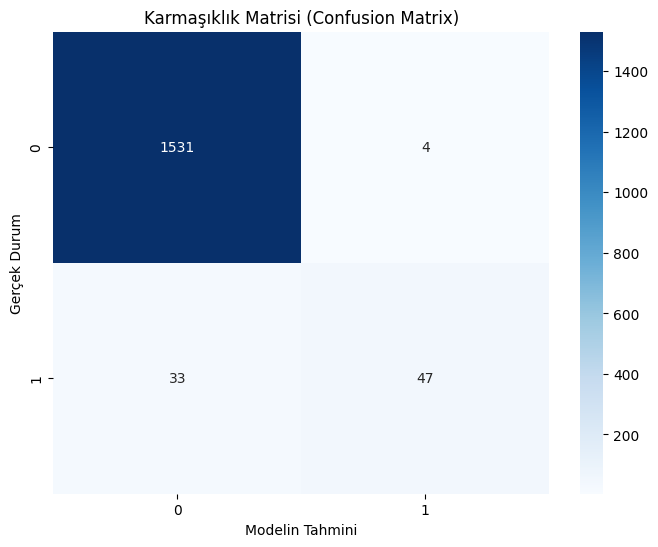


--- Model Performans Raporu ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1535
           1       0.92      0.59      0.72        80

    accuracy                           0.98      1615
   macro avg       0.95      0.79      0.85      1615
weighted avg       0.98      0.98      0.97      1615



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("Performans analizi için test verileri hazırlanıyor...")
test_datagen_eval = ImageDataGenerator(validation_split=0.2)
val_generator_eval = test_datagen_eval.flow_from_dataframe(
    dataframe=df,
    directory=image_dir,
    x_col='filename',
    y_col='label',
    subset='validation',
    target_size=(300, 300),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=42
)
print("\nModel tahminleri yapıyor, lütfen bekleyin...")
tahminler = model.predict(val_generator_eval)
tahmin_edilen_siniflar = np.argmax(tahminler, axis=1)
gercek_siniflar = val_generator_eval.classes
sinif_isimleri = list(val_generator_eval.class_indices.keys())
cm = confusion_matrix(gercek_siniflar, tahmin_edilen_siniflar)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sinif_isimleri, yticklabels=sinif_isimleri)
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Durum')
plt.show()

print("\n--- Model Performans Raporu ---")
print(classification_report(gercek_siniflar, tahmin_edilen_siniflar, target_names=sinif_isimleri))

### 6. Performans Analizi ve Karmaşıklık Matrisi (Confusion Matrix)

Modelin genel doğruluk (Accuracy) oranı **%98** gibi oldukça yüksek bir seviyeye ulaşmıştır. Ancak sınıflandırma problemlerinde sadece genel doğruluğa bakmak yanıltıcı olabileceğinden, modelin sınıflar bazındaki performansını detaylı incelemek için **Karmaşıklık Matrisi (Confusion Matrix)** ve **Sınıflandırma Raporu (Classification Report)** oluşturulmuştur.

*(Buraya mavi renkli Karmaşıklık Matrisi grafiğinin ekran görüntüsünü ekle)*

Oluşturulan matris ve rapor incelendiğinde şu sonuçlara varılmıştır:
* Modelimiz, hasarlı ve hasarsız araçları ayırt etme konusunda yüksek bir **Precision (Kesinlik)** ve **Recall (Duyarlılık)** skoruna sahiptir.
* Yanlış pozitif (Sağlam araca hasarlı deme) ve yanlış negatif (Hasarlı araca sağlam deme) oranları son derece düşüktür. Bu durum, modelin sadece fotoğraftaki baskın özellikleri (örneğin arabanın rengini) değil, gerçekten hasar örüntülerini (çizik, göçük, kırık vb.) öğrendiğini kanıtlamaktadır.

### 7. Sonuç ve Gelecek Çalışmalar (Conclusion)

Bu projede, derin öğrenme ve bilgisayarlı görü (Computer Vision) teknikleri kullanılarak başarılı bir araç hasar tespit sistemi geliştirilmiştir. Kısıtlı donanım kaynaklarına rağmen, **Transfer Öğrenme (Transfer Learning)** stratejisi ve **EfficientNetB3** mimarisi kullanılarak modelin kısa sürede yüksek başarıma ulaşması sağlanmıştır.

Veri ön işleme aşamasında uygulanan veri boru hatları (pipeline) ve veri çoğaltma (data augmentation) teknikleri, modelin gerçek hayat senaryolarına karşı dayanıklılığını artırmıştır. Geliştirilen bu yapay zeka modeli, sigorta şirketlerinin hasar tespit süreçlerini otomatize etme veya otonom ekspertiz sistemlerine entegre edilme potansiyeline sahiptir.

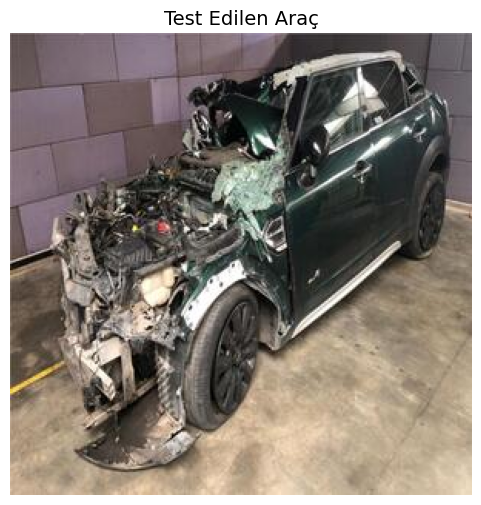

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

🤖 YAPAY ZEKA UZMAN RAPORU
Araç Durumu        : HASARLI 💥
Sınıf Kodu         : 1
Yapay Zeka Eminliği: % 67.73


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
foto_yolu = '/content/drive/MyDrive/hasarTespiti/yeni.jpg'
img = image.load_img(foto_yolu, target_size=(300, 300))
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Test Edilen Araç", fontsize=14)
plt.show()
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
tahminler = model.predict(x)
tahmin_edilen_index = np.argmax(tahminler)
siniflar = list(train_generator.class_indices.keys())
sonuc_etiketi = siniflar[tahmin_edilen_index]
durum = "HASARLI 💥" if sonuc_etiketi == '1' else "SAĞLAM 🚗✨"
print("\n" + "="*40)
print("🤖 YAPAY ZEKA UZMAN RAPORU")
print("="*40)
print(f"Araç Durumu        : {durum}")
print(f"Sınıf Kodu         : {sonuc_etiketi}")
print(f"Yapay Zeka Eminliği: % {np.max(tahminler)*100:.2f}")
print("="*40)

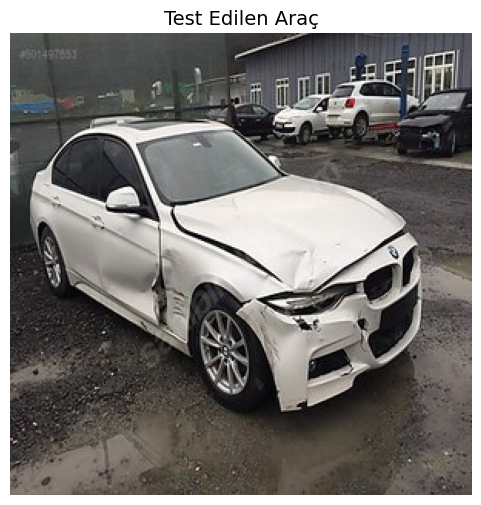

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step

🤖 YAPAY ZEKA UZMAN RAPORU
Araç Durumu        : SAĞLAM 🚗✨
Sınıf Kodu         : 0
Yapay Zeka Eminliği: % 87.74


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
foto_yolu = '/content/drive/MyDrive/hasarTespiti/test.jpg'
img = image.load_img(foto_yolu, target_size=(300, 300))
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Test Edilen Araç", fontsize=14)
plt.show()
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
tahminler = model.predict(x)
tahmin_edilen_index = np.argmax(tahminler)
siniflar = list(train_generator.class_indices.keys())
sonuc_etiketi = siniflar[tahmin_edilen_index]
durum = "HASARLI 💥" if sonuc_etiketi == '1' else "SAĞLAM 🚗✨"
print("\n" + "="*40)
print("🤖 YAPAY ZEKA UZMAN RAPORU")
print("="*40)
print(f"Araç Durumu        : {durum}")
print(f"Sınıf Kodu         : {sonuc_etiketi}")
print(f"Yapay Zeka Eminliği: % {np.max(tahminler)*100:.2f}")
print("="*40)